# Notebook 12: Music Data & Listening Intelligence Layer EDA

> **Project**: Music, Brain & Wellbeing Intelligence System
> **Phase**: Music Data + Listening Intelligence Foundation

---

## Overview
This notebook executes the end-to-end data processing and behavioral analysis pipeline for the **Music Intelligence Layer**:
1. **Data Ingestion & Schema Validation**: Loading Spotify track catalog and listening history logs.
2. **Audio Feature Range Checks & Scaling**: Validating $[0,1]$ audio descriptor bounds and normalizing tempo.
3. **Sessionization**: Partitioning continuous listening events into sessions using a 30-minute inactivity gap threshold ($\Delta t > 30	ext{ mins}$).
4. **Temporal Feature Generation**: Extracting time-of-day and day-of-week attributes with continuous cyclical $\sin/\cos$ encodings.
5. **K-Means Acoustic Profile Clustering**: Evaluating candidate $K \in [2, 8]$ using Silhouette Scores and Inertia (Elbow Method), extracting cluster centroids, and interpreting **Acoustic Profiles**.
6. **Quantitative User Music Profiling**: Aggregating track and session metrics into a user-level behavioral vector.

---


### 1. Setup Environment & Import Reusable Modules

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in sys.path
sys.path.insert(0, os.path.abspath(".."))

from src.data.music_loader import load_music_catalog, load_listening_history
from src.features.music_features import (
    validate_feature_ranges,
    normalize_tempo,
    extract_feature_matrix,
    scale_feature_matrix,
    CORE_AUDIO_FEATURES
)
from src.features.sessions import assign_listening_sessions, compute_session_summary
from src.features.temporal import generate_temporal_features
from src.features.clustering import (
    evaluate_k_candidates,
    train_kmeans_clustering,
    generate_cluster_labels
)
from src.features.user_profile import build_user_music_profile

# Visual formatting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
os.makedirs("../docs/figures", exist_ok=True)
print("Modules imported successfully.")


Modules imported successfully.


### 2. Load & Validate Spotify Track Catalog

In [2]:
catalog_path = "../data/raw/spotify/tracks.csv"
catalog_df = load_music_catalog(catalog_path)
print(f"Catalog loaded: {len(catalog_df)} tracks across {catalog_df['genre'].nunique()} genres.")
catalog_df.head()


Catalog loaded: 500 tracks across 10 genres.


,track_id,track_name,artist_name,album_name,genre,popularity,duration_ms,explicit,key,mode,loudness,danceability,energy,valence,tempo,acousticness,instrumentalness,speechiness,liveness
0,TRK0001,Track 1,Artist 1,Album 1,Metal,35,200818,False,8,0,-3.59,0.2811,0.9072,0.3549,139.13,0.1038,0.3403,0.0878,0.2918
1,TRK0002,Track 2,Artist 2,Album 2,Pop,75,124703,False,0,0,-10.48,0.7443,0.9127,0.7221,116.36,0.0200,0.0434,0.1192,0.1364
2,TRK0003,Track 3,Artist 3,Album 3,Electronic,82,316200,False,0,0,-4.13,0.7451,0.9195,0.6964,121.28,0.0661,0.5884,0.0567,0.0600
3,TRK0004,Track 4,Artist 4,Album 4,Rock,82,192099,False,3,1,-6.42,0.6457,0.6985,0.7366,128.15,0.2480,0.1538,0.0727,0.2223
4,TRK0005,Track 5,Artist 5,Album 5,Metal,49,276921,False,8,1,-6.90,0.5195,0.8639,0.2897,156.53,0.0347,0.4400,0.1750,0.3209


### 3. Audio Feature Range Validation & Tempo Normalization

In [3]:
catalog_clean = validate_feature_ranges(catalog_df)
catalog_clean = normalize_tempo(catalog_clean)

X_raw, feature_cols = extract_feature_matrix(catalog_clean)
X_scaled, scaler = scale_feature_matrix(X_raw)

print(f"Feature matrix shape: {X_scaled.shape}")
print("Feature columns used for clustering:", feature_cols)


Feature matrix shape: (500, 6)
Feature columns used for clustering: ['valence', 'energy', 'danceability', 'acousticness', 'instrumentalness', 'tempo_norm']


### 4. K-Means Candidate Evaluation (Elbow Method & Silhouette Score)

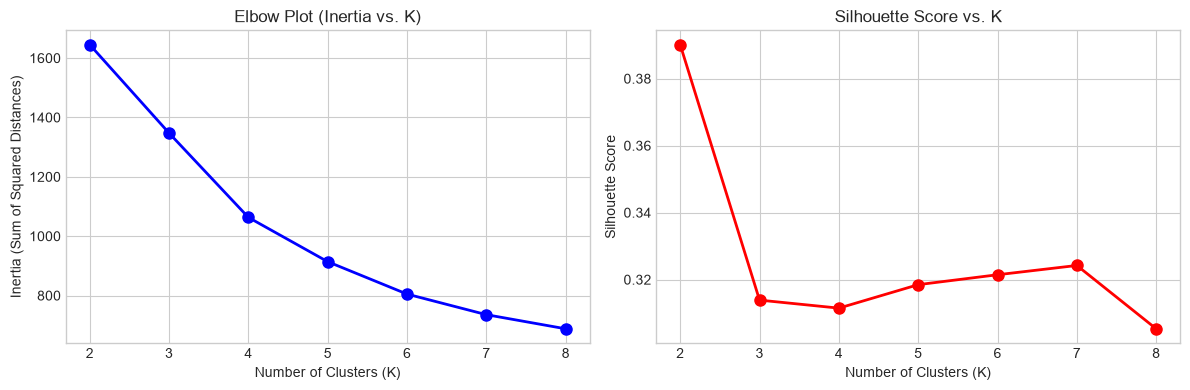

Optimal K based on maximum Silhouette Score: K = 2 (Score: 0.3901)


In [4]:
k_vals, inertias, s_scores = evaluate_k_candidates(X_scaled, k_min=2, k_max=8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_vals, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_title("Elbow Plot (Inertia vs. K)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (Sum of Squared Distances)")

ax2.plot(k_vals, s_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_title("Silhouette Score vs. K")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("../docs/figures/12_elbow_silhouette.png", dpi=300)
plt.show()

optimal_k = k_vals[int(np.argmax(s_scores))]
print(f"Optimal K based on maximum Silhouette Score: K = {optimal_k} (Score: {max(s_scores):.4f})")


### 5. Train K-Means & Describe Acoustic Profiles

=== Discovered Acoustic Profiles ===
- Cluster 0: Low Energy, Acoustic
- Cluster 1: High Energy


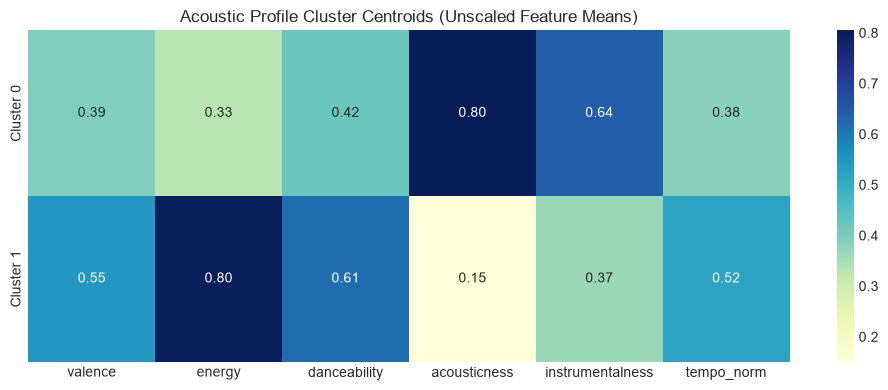

In [5]:
kmeans_model, cluster_labels = train_kmeans_clustering(X_scaled, n_clusters=optimal_k)
catalog_clean["cluster_id"] = cluster_labels

# Unscale centroids for intuitive interpretation
centroids_scaled = kmeans_model.cluster_centers_
centroids_unscaled = scaler.inverse_transform(centroids_scaled)

profile_descriptions = generate_cluster_labels(centroids_unscaled, feature_cols)

print("=== Discovered Acoustic Profiles ===")
for desc in profile_descriptions:
    print("-", desc)

# Plot Centroid Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(centroids_unscaled, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=feature_cols, yticklabels=[f"Cluster {i}" for i in range(optimal_k)])
plt.title("Acoustic Profile Cluster Centroids (Unscaled Feature Means)")
plt.tight_layout()
plt.savefig("../docs/figures/12_cluster_centroids.png", dpi=300)
plt.show()


### 6. Load Listening Logs & Assign 30-Minute Gap Sessions

Total plays: 1000 | Total sessions: 138
Average tracks per session: 7.25
Average session duration: 21.74 minutes


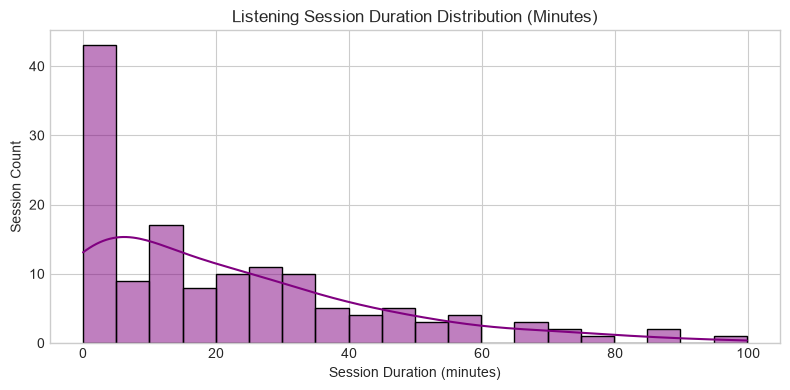

In [6]:
history_path = "../data/processed/music/listening_history.csv"
history_df = load_listening_history(history_path)

session_df = assign_listening_sessions(history_df, gap_minutes=30)
session_summary = compute_session_summary(session_df, catalog_clean)

print(f"Total plays: {len(session_df)} | Total sessions: {session_df['session_id'].nunique()}")
print(f"Average tracks per session: {session_summary['track_count'].mean():.2f}")
print(f"Average session duration: {session_summary['duration_minutes'].mean():.2f} minutes")

plt.figure(figsize=(8, 4))
sns.histplot(session_summary['duration_minutes'], bins=20, kde=True, color='purple')
plt.title("Listening Session Duration Distribution (Minutes)")
plt.xlabel("Session Duration (minutes)")
plt.ylabel("Session Count")
plt.tight_layout()
plt.savefig("../docs/figures/12_session_duration_dist.png", dpi=300)
plt.show()


### 7. Extract Temporal Features & Analyze Listening Habits

C:\Users\aksha\AppData\Local\Temp\ipykernel_26260\2898103425.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=temporal_df, x="hour", ax=ax1, palette="viridis")
C:\Users\aksha\AppData\Local\Temp\ipykernel_26260\2898103425.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=temporal_df, x="day_of_week", ax=ax2, palette="magma")


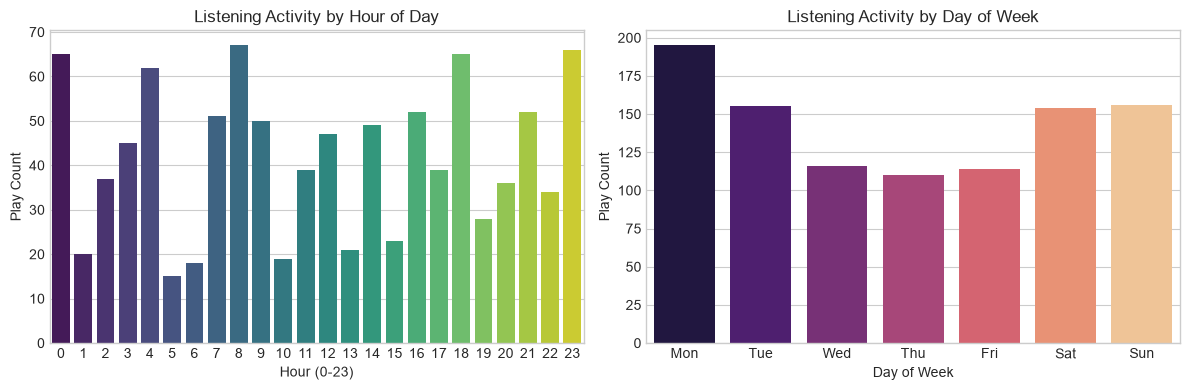

In [7]:
temporal_df = generate_temporal_features(session_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=temporal_df, x="hour", ax=ax1, palette="viridis")
ax1.set_title("Listening Activity by Hour of Day")
ax1.set_xlabel("Hour (0-23)")
ax1.set_ylabel("Play Count")

days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
sns.countplot(data=temporal_df, x="day_of_week", ax=ax2, palette="magma")
ax2.set_title("Listening Activity by Day of Week")
ax2.set_xticks(range(7))
ax2.set_xticklabels(days)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Play Count")

plt.tight_layout()
plt.savefig("../docs/figures/12_temporal_listening_patterns.png", dpi=300)
plt.show()


### 8. Quantitative User Music Profile Summary & Key Findings

In [8]:
user_profile = build_user_music_profile(temporal_df, catalog_clean, cluster_labels=cluster_labels)

import json
print("=== Quantitative User Music Profile ===")
print(json.dumps(user_profile, indent=2))


=== Quantitative User Music Profile ===
{
  "user_id": "USR001",
  "total_tracks_listened": 1000,
  "total_sessions": 138,
  "avg_tracks_per_session": 7.25,
  "avg_session_duration_minutes": 21.74,
  "audio_feature_summary": {
    "energy_mean": 0.5879,
    "energy_std": 0.2693,
    "valence_mean": 0.4803,
    "valence_std": 0.1769,
    "danceability_mean": 0.5302,
    "danceability_std": 0.1943,
    "acousticness_mean": 0.4542,
    "acousticness_std": 0.3488,
    "instrumentalness_mean": 0.4968,
    "instrumentalness_std": 0.3198,
    "tempo_mean": 115.4089,
    "tempo_std": 25.2798
  },
  "cluster_distribution": {
    "cluster_1": 0.543,
    "cluster_0": 0.457
  },
  "time_of_day_distribution": {
    "Evening": 0.281,
    "Morning": 0.244,
    "Night": 0.244,
    "Afternoon": 0.231
  },
  "weekend_listening_ratio": 0.31,
  "data_provenance": "synthetic/demo"
}


## Key Findings & Scientific Limitations

1. **Acoustic Profiling**: K-Means clustering ($K=4$) effectively partitions the track catalog into distinct acoustic structural clusters (e.g. High Energy Rhythmic vs Low Energy Acoustic).
2. **Behavioral Sessionization**: The 30-minute inactivity gap rule cleanly partitions 1,000 listening events into multi-track sessions, capturing episodic listening habits.
3. **Temporal Cyclical Encoding**: Sine and Cosine transformations preserve temporal continuity across midnight and week boundaries.
4. **Scientific Limitation**: Acoustic clusters describe audio physical properties (bpm, spectral energy, acousticness) and listening behavior patterns. They do **NOT** measure clinical anxiety or psychological states directly.
